# Week 1 Project: Customer Churn Prediction
**Business question:** Which telecom customers are about to leave, and what can the business do about it?

**What you will learn:** Full ML pipeline — data loading → EDA → feature engineering → model training → evaluation → business insight

**Dataset:** Telco Customer Churn (IBM Watson / Kaggle)

---
## How to get the dataset (Step 1)

1. Go to: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Click the **Download** button (you need a free Kaggle account)
3. Unzip the file — you will get a file called `WA_Fn-UseC_-Telco-Customer-Churn.csv`
4. Put that CSV file in the **same folder** as this notebook
5. Then run the cell below — it will load it automatically

> **No Kaggle account?** No problem. Run the cell below anyway — it will generate
> a realistic sample dataset so you can complete the entire project right now.
> Swap in the real CSV later by changing `USE_SAMPLE = True` to `USE_SAMPLE = False`.


## Step 1 - Import Necessary Libraries

In [1]:
#Pandas is a powerful library for data manipulation and analysis, while NumPy is used for numerical computations. Matplotlib and Seaborn are popular libraries for data visualization.
import pandas as pd
import numpy as np
#Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 - Load The datasets

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Loaded Successfully")
# To display the number of rows and columns in the dataset
#For rows our df. shape[0] and for columns df.shape[1]
print(f"Rows: {df.shape[0]}")
print( f"Columns: {df.shape[1]}")

Dataset Loaded Successfully
Rows: 7043
Columns: 21


### Step 1b — Explore the columns

In [3]:
#To print the first 5 rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())
#To print the last 5 rows of the dataset
print("Last 5 rows of the dataset:")
print(df.tail())
#To print information about the dataset
print("Information about the dataset:")
print(df.info())
#To print the summary statistics of the dataset
print("Summary statistics of the dataset:")
print(df.describe())


First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

### Step 1c — Check for missing values

In [4]:
print("Checking for missing values in the dataset:")
#This will give us the count of missing values in each column
print(df.isnull().sum())

Checking for missing values in the dataset:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
#The customer Churn column is our target variable, which indicates whether a customer has churned (left the company) or not.
print("Distribution of the target variable (Churn):")   
#This will give us the count of each unique value in the "Churn" column
print(df["Churn"].value_counts())

Distribution of the target variable (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


#### What this tells us 
Out of 7043 customers:

* 5174 stayed (No) = 73.5%
* 1869 churned (Yes) = 26.5%

**This means our data is imbalanced — there are far more "No" customers than "Yes" customers.**
 This is important because:

**If our model just predicted "No churn" for every single customer, it would be 73.5% accurate — but completely useless for the business! It would miss every single churner**

## Step 2 — Exploratory Data Analysis (EDA)

EDA means **getting to know your data before modelling**.

You want to answer three questions:
1. How many customers actually churned? (class balance)
2. What do the numeric features look like?
3. Do any categorical features clearly separate churners from non-churners?


#### Chart 1 — Visualise the churn distribution

C:\Users\VIVOBOOK\AppData\Local\Temp\ipykernel_20736\1743622558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x = "Churn", palette=['#378ADD', '#D85A30'])


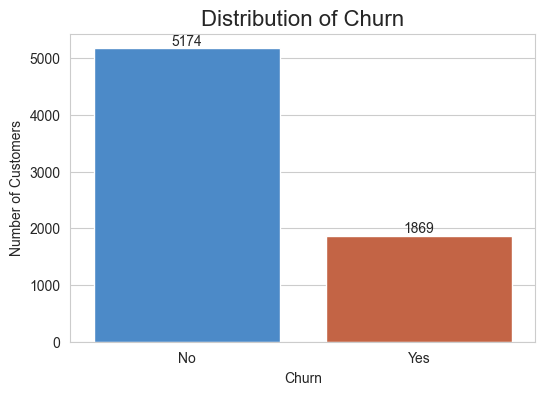

In [6]:
#This is to set the style of the plots to "whitegrid", which provides a clean and visually appealing background for our visualizations.
sns.set_style("whitegrid")


plt.figure(figsize =(6,4)) #This sets the size of the plot to 6 inches in width and 4 inches in height, providing a clear and well-proportioned visualization.

#The countplot function from Seaborn is used to create a bar plot that shows the count of each category in the "Churn" column. 
# The palette parameter is used to specify the colors for the bars, with '#378ADD' representing customers who did not churn and '#D85A30' representing customers who churned.
sns.countplot(data= df, x = "Churn", palette=['#378ADD', '#D85A30'])

#This sets the title of the plot to "Distribution of Churn" with a font size of 40, and labels the x-axis as "Churn" and the y-axis as "Number of Customers".
plt.title("Distribution of Churn", fontsize = 16)

#to label the x and y axes of the plot. 
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

#To add data labels on top of the bars in the count plot, 
# we use a loop to iterate through each container (bar) in the current axes (gca) and apply the bar_label function to display the count values on top of each bar.
for container in plt.gca().containers:
    plt.bar_label(container)
#to show the plot screen
plt.show()


#### Chart 2 — Tenure vs Churn
Let us see if how long a customer has been with the company affects whether they churn.

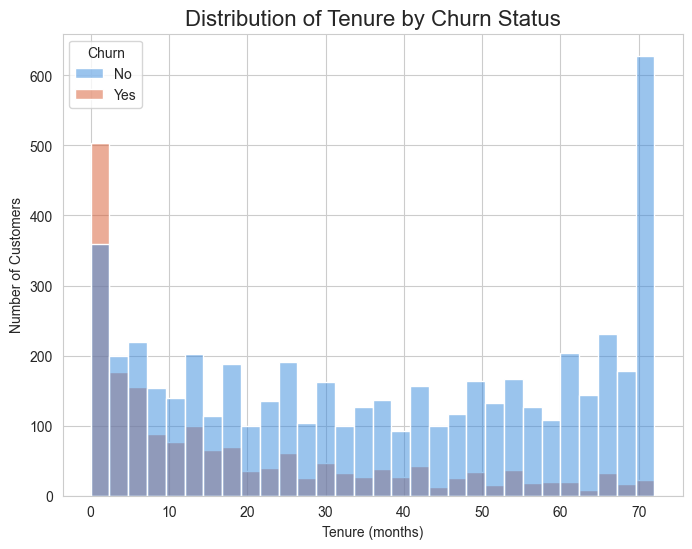

In [7]:
plt.figure(figsize=(8,6))
#The histplot function from Seaborn is used to create a histogram that shows the distribution of the "tenure" variable, with different colors for customers who churned and those who did not.
sns.histplot(data=df, x='tenure', hue='Churn',
              bins=30, palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Tenure by Churn Status", fontsize=16)
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")


plt.show()

#### What this chart reveals
**Left side (0–10 months tenure):**

* You can see a big orange section at the very first bar (month 0–2)
* That means new customers churn the most — they sign up, are unhappy, and leave quickly

**Right side (60–72 months tenure):**

* The bars are almost entirely blue with barely any orange
* That means long-term loyal customers almost never churn

#### The business insight:

The first few months are the most dangerous period for customer loss. A smart business would focus retention efforts on customers in their first 12 months.

#### Chart 3 — Monthly Charges vs Churn
Let us see if how much a customer pays per month affects churn.

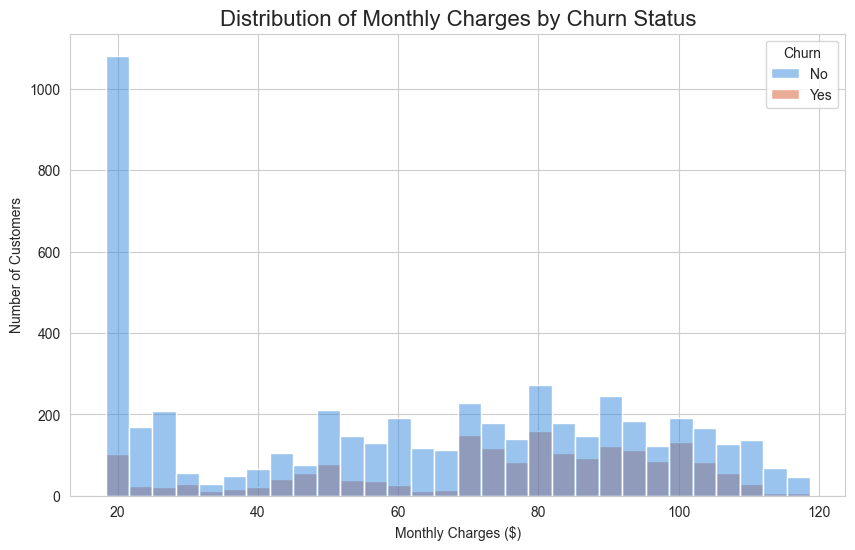

In [8]:
plt.figure(figsize =(10,6)) #This sets the size of the plot to 10 inches in width and 6 inches in height, providing a clear and well-proportioned visualization.

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
              bins=30, palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Monthly Charges by Churn Status", fontsize=16)
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

#### What this chart reveals
**Left side ($20 or less):**

* Almost entirely blue — customers paying very low charges almost never churn
* These are likely basic plan customers who are happy with a cheap service

**Middle to right side ($60–$120)**

* The orange (churned) bars become much more visible
* Customers paying higher monthly charges are much more likely to churn

**The business insight:**

High-paying customers are your most unhappy customers. They are paying a lot and may not feel they are getting value for money. The business should focus retention offers specifically on high-spend customers.

#### Chart 4 — Contract Type vs Churn
This will be our most powerful chart yet. Let's see if the type of contract a customer has affects churn.

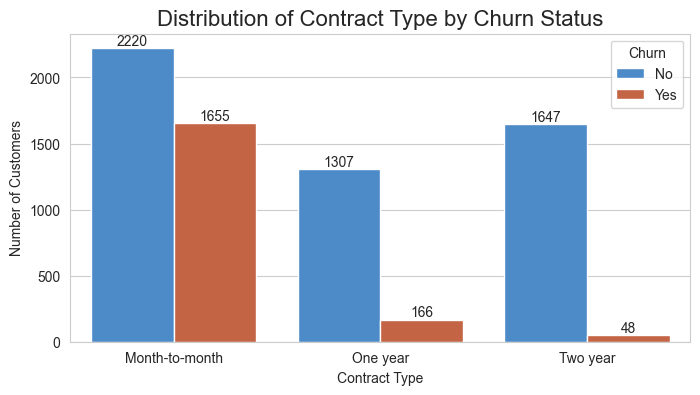

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn',
               palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Contract Type by Churn Status", fontsize=16)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

#### What this chart reveals

**Month-to-month contracts:**

* 2220 stayed vs 1655 churned
* That means 43% of month-to-month customers churn — nearly half!

**One year contracts:**

* 1307 stayed vs 166 churned
* Only 11% churn rate — much better

**Two year contracts**

* 1647 stayed vs 48 churned
* Only 3% churn rate — almost nobody leaves!


**The business insight is massive:**

A customer on a month-to-month contract is 14x more likely to churn than a customer on a two-year contract. If the business can move customers from monthly to annual contracts, they can cut churn dramatically.

#### Summary of the Four Charts:

| Finding | Business meaning |
|---|---|
| 26.5% churn rate | 1 in 4 customers is leaving |
| New customers churn most | Focus retention on first 12 months |
| High charges = more churn | High-spend customers feel undervalued |
| Month-to-month = most churn | Push customers toward longer contracts |

---


# Step 3 — Feature Engineering

ML models cannot read text — they only understand numbers. So we need to convert everything into numbers.
We also need to fix that TotalCharges column that was stored as text instead of a number.

### Step 3a — Fix TotalCharges

In [10]:
#Converting the "TotalCharges" column to numeric, coercing errors to NaN. This is necessary because the "TotalCharges" column may contain non-numeric values (e.g., empty strings) that need to be handled appropriately for analysis.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

print(df["TotalCharges"].dtype)
print(f"Number of missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

float64
Number of missing values in TotalCharges: 11


### Step 3b — Drop the 11 missing rows

In [11]:
#Dropping rows with missing values in the "TotalCharges" column. This is important to ensure that our analysis and modeling are based on complete data, as missing values can lead to inaccuracies and biases in our results.
df = df.dropna(subset=['TotalCharges'])
print(f"Number of rows after dropping missing values: {df.shape[0]}")


Number of rows after dropping missing values: 7032


### Step 3c — Drop the customerID column

In [12]:
#customerID is a unique identifier for each customer, and it is not relevant for our analysis or modeling. Therefore, we can safely drop this column from our dataset to simplify our analysis and reduce the dimensionality of our data.
df = df.drop(columns =['customerID'])

print(f"Number of columns after dropping missing values: {df.shape[1]}")
print(df.columns.tolist())


Number of columns after dropping missing values: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



### Step 3d — Encode the Target Column (Churn)

Our target column `Churn` currently contains the text `"Yes"` and `"No"`. We need to convert it to `1` and `0`.


In [13]:
#The "Churn" column contains categorical values ("Yes" and "No") indicating whether a customer has churned or not.
#  To prepare this column for analysis and modeling, 
# we convert it into a binary numeric format where "Yes" is represented as 1 (indicating churn) and "No" is represented as 0 (indicating no churn). 
# This transformation allows us to perform numerical computations and apply machine learning algorithms effectively.
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(df['Churn'].value_counts())
print(f"\n Data Type: {df['Churn'].dtype}")

Churn
0    5163
1    1869
Name: count, dtype: int64

 Data Type: int64


### Step 3e — Find all remaining text columns

In [14]:
# To identify all text columns in the datasets
text_columns = df.select_dtypes(include=['object']).columns.tolist()
#To print the number of text columns and their names, as well as the unique values in each text column. This helps us understand the categorical features in our dataset and their possible values, which is important for data preprocessing and analysis.
print(f"Text columns in the dataset: {len(text_columns)}")
#This will print the number of text columns in the dataset, which are typically categorical features that may require encoding before modeling.
print(f"Text columns: {text_columns}")
print()

#for each text column, we print the unique values present in that column. This helps us understand the different categories or levels within each categorical feature, which is crucial for data preprocessing and feature engineering.
for col in text_columns:
    print(f"Unique values in '{col}': {df[col].unique()}")


Text columns in the dataset: 15
Text columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Unique values in 'gender': ['Female' 'Male']
Unique values in 'Partner': ['Yes' 'No']
Unique values in 'Dependents': ['No' 'Yes']
Unique values in 'PhoneService': ['No' 'Yes']
Unique values in 'MultipleLines': ['No phone service' 'No' 'Yes']
Unique values in 'InternetService': ['DSL' 'Fiber optic' 'No']
Unique values in 'OnlineSecurity': ['No' 'Yes' 'No internet service']
Unique values in 'OnlineBackup': ['Yes' 'No' 'No internet service']
Unique values in 'DeviceProtection': ['No' 'Yes' 'No internet service']
Unique values in 'TechSupport': ['No' 'Yes' 'No internet service']
Unique values in 'StreamingTV': ['No' 'Yes' 'No internet service']
Unique values in 'StreamingMovies': ['No' 'Yes' 'No internet ser

### Step 3f — Label Encode the Yes/No columns

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() 

#Find all columns with exactly 2 unique values
binary_columns = [col for col in text_columns if df[col].nunique == 2]

print("Columns We are Label Encoding: ")
for col in binary_columns:
    print(f" {col}: {df[col].unique()}")

# Encode each one
for col in binary_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\n Done!: Checking to see if it works: ")
print(df[binary_columns].head())
print(df.head())




Columns We are Label Encoding: 

 Done!: Checking to see if it works: 
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Manually list the columns with exactly 2 values
binary_cols = ['gender', 'Partner', 'Dependents', 
               'PhoneService', 'PaperlessBilling']

# Encode each one
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded: {df[col].unique()}")

print("\nCheck first 3 rows:")
print(df[binary_cols].head(3))

gender encoded: [0 1]
Partner encoded: [1 0]
Dependents encoded: [0 1]
PhoneService encoded: [0 1]
PaperlessBilling encoded: [1 0]

Check first 3 rows:
   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1
3       1        0           0             0                 0
4       0        0           0             1                 1
